
---
date: "2026-08-16"
date-modified: last-modified
format:
  html:
    toc: true
---


# Gaussian Processes and Covariance Kernels

A **[Gaussian process](gaussian-processes.ipynb)** is the continuous generalization of the [multivariate normal distribution](multivariate-normal-distribution.ipynb) to function spaces. Because all of its finite-dimensional distributions are normal, a Gaussian process is uniquely determined by its **mean function** and its **covariance kernel**. 

Gaussian processes form the mathematical foundation for standard **Brownian motion**, the **Ornstein-Uhlenbeck mean-reverting process**, and modern non-parametric Bayesian machine learning. Examining the pathological properties of continuous-time independent Gaussian noise reveals why non-trivial covariance structures are essential for continuous stochastic calculus.

---


## 1\. Definition and Finite-Dimensional Characterization

In general, defining a [stochastic process](stochastic-processes-foundations.ipynb) requires specifying an infinite family of consistent joint distributions across all finite subsets of time. For Gaussian processes, the property of normality drastically simplifies this requirement.

::: {#def-gaussian-process}
## Gaussian Process
A real-valued stochastic process $X = (X_t)_{t \in T}$ indexed by $T \subseteq \mathbb{R}$ is called a **Gaussian process** if for every integer $n \ge 1$ and every finite collection of distinct time indices $t_1, t_2, \dots, t_n \in T$, the random vector:
$$
\mathbf{X} = \left( X_{t_1}, X_{t_2}, \dots, X_{t_n} \right)^T
$$
has a [multivariate normal distribution](multivariate-normal-distribution.ipynb) on $\mathbb{R}^n$.
:::

::: {#thm-gaussian-process-uniqueness}
## Uniqueness via Mean and Covariance Functions
The full probability law of a Gaussian process $(X_t)_{t \in T}$ is uniquely and completely determined by two deterministic functions:

1. **Mean Function:** $\mu: T \to \mathbb{R}$, defined for each $t \in T$ by:
$$
\mu(t) = \mathbb{E}\left[ X_t \right]
$$
2. **Covariance Kernel (Covariance Function):** $C: T \times T \to \mathbb{R}$, defined for all $s, t \in T$ by:
$$
C(s, t) = \text{Cov}\left( X_s, X_t \right) = \mathbb{E}\left[ \left( X_s - \mu(s) \right)\left( X_t - \mu(t) \right) \right]
$$

For any collection of time indices $\mathbf{t} = (t_1, \dots, t_n)^T$, the finite-dimensional vector $(X_{t_1}, \dots, X_{t_n})^T$ is distributed as $\mathcal{N}(\boldsymbol{\mu}_{\mathbf{t}}, \boldsymbol{\Sigma}_{\mathbf{t}})$, where:
$$
\boldsymbol{\mu}_{\mathbf{t}} = \begin{pmatrix} \mu(t_1) \\ \vdots \\ \mu(t_n) \end{pmatrix}, \qquad \boldsymbol{\Sigma}_{\mathbf{t}} = \begin{pmatrix} C(t_1, t_1) & C(t_1, t_2) & \dots & C(t_1, t_n) \\ C(t_2, t_1) & C(t_2, t_2) & \dots & C(t_2, t_n) \\ \vdots & \vdots & \ddots & \vdots \\ C(t_n, t_1) & C(t_n, t_2) & \dots & C(t_n, t_n) \end{pmatrix}
$$
:::

::: {.callout-note}
## Intuition: Dimensionality Reduction of Probability Law
For an arbitrary stochastic process, describing all $n$-dimensional joint distributions requires specifying complex $n$-variable joint characteristic functions or densities for every $n \ge 1$. 

Because any multivariate Gaussian distribution is entirely parameterized by its first two moments (mean vector and covariance matrix), specifying the bivariate function $C(s, t)$ and univariate function $\mu(t)$ completely pins down the joint distribution for *any* finite subset of arbitrary size $n$.
:::


## 2\. Covariance Kernels and Positive Semi-Definiteness

Not every two-variable function $C(s, t)$ can serve as the covariance kernel of a Gaussian process. The function must satisfy symmetry and positive semi-definiteness to guarantee that all generated covariance matrices $\boldsymbol{\Sigma}_{\mathbf{t}}$ are valid.

::: {#def-covariance-kernel}
## Positive Semi-Definite Kernel
A real-valued symmetric function $C: T \times T \to \mathbb{R}$ (where $C(s, t) = C(t, s)$) is called a **positive semi-definite kernel** on $T$ if for every integer $n \ge 1$, every choice of time points $t_1, \dots, t_n \in T$, and all real coefficients $a_1, \dots, a_n \in \mathbb{R}$:
$$
\sum_{i=1}^n \sum_{j=1}^n a_i a_j C(t_i, t_j) \ge 0
$$
:::

::: {#prp-positive-semidefiniteness}
## Covariance Kernels are Positive Semi-Definite
Every valid covariance function $C(s, t) = \text{Cov}(X_s, X_t)$ of a stochastic process is positive semi-definite. Conversely, given any mean function $\mu: T \to \mathbb{R}$ and any positive semi-definite kernel $C: T \times T \to \mathbb{R}$, there exists a unique Gaussian process $(X_t)_{t \in T}$ with mean $\mu$ and covariance $C$.
:::

::: {.callout-tip collapse="true"}
## Proof of Positive Semi-Definiteness
Let $(X_t)_{t \in T}$ be a stochastic process with mean function $\mu(t)$ and covariance function $C(s, t)$. Let $t_1, \dots, t_n \in T$ and $a_1, \dots, a_n \in \mathbb{R}$ be arbitrary. Define the composite scalar random variable $Y$ as the linear combination:
$$
Y = \sum_{i=1}^n a_i \left( X_{t_i} - \mu(t_i) \right)
$$
We compute the variance of $Y$:
$$
\begin{aligned}
\text{Var}(Y) &= \mathbb{E}\left[ Y^2 \right] = \mathbb{E}\left[ \left( \sum_{i=1}^n a_i (X_{t_i} - \mu(t_i)) \right) \left( \sum_{j=1}^n a_j (X_{t_j} - \mu(t_j)) \right) \right] \\
&= \sum_{i=1}^n \sum_{j=1}^n a_i a_j \mathbb{E}\left[ (X_{t_i} - \mu(t_i))(X_{t_j} - \mu(t_j)) \right] \\
&= \sum_{i=1}^n \sum_{j=1}^n a_i a_j C(t_i, t_j)
\end{aligned}
$$
Since the variance of any real random variable is non-negative ($\text{Var}(Y) \ge 0$), it immediately follows that:
$$
\sum_{i=1}^n \sum_{j=1}^n a_i a_j C(t_i, t_j) \ge 0 \quad \blacksquare
$$
:::


## 3\. The Continuous White Noise Pathology

To understand why continuous-time stochastic calculus cannot be formulated with purely independent continuous increments, consider the canonical continuous-time i.i.d. normal process.

::: {#def-continuous-white-noise}
## Continuous-Time i.i.d. Gaussian Process (Continuous White Noise)
Let $T = [0, 1]$. Consider the Gaussian process $(X_t)_{t \in [0, 1]}$ defined by:
$$
X_t \stackrel{i.i.d.}{\sim} \mathcal{N}(0, 1), \quad \forall t \in [0, 1]
$$
Its mean and covariance functions are:
$$
\mu(t) = 0, \qquad C(s, t) = \begin{cases} 1, & s = t \\ 0, & s \ne t \end{cases} = \mathbf{1}_{\{s = t\}}
$$
:::

::: {#prp-white-noise-pathology}
## Pathological Properties of Continuous White Noise
The continuous white noise process $(X_t)_{t \in [0, 1]}$ satisfies all consistency conditions, yet possesses extreme path pathologies:

1. **Nowhere Continuous:** With probability 1, the sample path $t \mapsto X_t(\omega)$ is discontinuous at *every* point in $[0, 1]$.
2. **Unbounded on Any Interval:** For any non-empty sub-interval $(a, b) \subseteq [0, 1]$:
$$
\sup_{t \in (a, b)} X_t(\omega) = +\infty \quad \text{and} \quad \inf_{t \in (a, b)} X_t(\omega) = -\infty \quad \text{almost surely}
$$
3. **Non-Measurability:** The sample path $t \mapsto X_t(\omega)$ is not Lebesgue measurable as a function on $[0, 1]$, making standard Riemann or Lebesgue integration $\int_0^1 X_t(\omega) dt$ undefined.
:::

::: {.callout-tip collapse="true"}
## Proof of Nowhere Continuity and Unboundedness
Let $(a, b) \subset [0, 1]$ be an arbitrary interval with $a < b$. Choose a countable infinite sequence of distinct points $(t_k)_{k=1}^\infty \subset (a, b)$. Since $t_k \ne t_m$ for $k \ne m$, the random variables $(X_{t_k})_{k=1}^\infty$ are mutually independent standard normals $\mathcal{N}(0, 1)$.

For any fixed constant $M > 0$, the probability that any single $X_{t_k} \le M$ is $p = \Phi(M) < 1$. By mutual independence:
$$
\mathbb{P}\left( \sup_{t \in (a, b)} X_t \le M \right) \le \mathbb{P}\left( X_{t_k} \le M, \, \forall k=1, \dots, K \right) = \prod_{k=1}^K \mathbb{P}(X_{t_k} \le M) = \Phi(M)^K
$$
Taking the limit as $K \to \infty$, since $0 < \Phi(M) < 1$:
$$
\lim_{K \to \infty} \Phi(M)^K = 0 \implies \mathbb{P}\left( \sup_{t \in (a, b)} X_t \le M \right) = 0
$$
Since this holds for every $M > 0$, $\sup_{t \in (a, b)} X_t(\omega) = +\infty$ almost surely. By identical symmetry, $\inf_{t \in (a, b)} X_t(\omega) = -\infty$ almost surely.

Because the supremum is infinite on every open sub-interval, $t \mapsto X_t(\omega)$ cannot be continuous at any point in $[0, 1]$. $\blacksquare$
:::

::: {.callout-warning}
## Why Itô Calculus Uses Brownian Motion Instead of White Noise
The pathology above demonstrates that constructing continuous-time models by placing independent Gaussian variables at each instant $t$ produces mathematical nonsense (sample paths resemble an infinitely dense forest of disconnected spikes). 

To obtain continuous trajectories $t \mapsto X_t(\omega)$, the covariance kernel $C(s, t)$ must be **continuous** in $(s, t)$. Standard Brownian motion achieves this with $C(s, t) = \min(s, t)$, ensuring that nearby states are strongly correlated.


## 4\. Canonical Covariance Kernels in Stochastic Calculus

Below are the primary covariance kernels underpinning continuous-time financial and physical processes:

| Stochastic Process | Covariance Kernel $C(s, t)$ | Mean $\mu(t)$ | Sample Path Property |
| :--- | :--- | :--- | :--- |
| **Continuous White Noise** | $\sigma^2 \mathbf{1}_{\{s = t\}}$ | $0$ | Nowhere continuous, unmeasurable |
| **Standard Brownian Motion** | $\min(s, t)$ | $0$ | Continuous almost surely, nowhere differentiable |
| **Brownian Bridge ($B_0 = B_1 = 0$)** | $\min(s, t) - st$ on $[0, 1]$ | $0$ | Continuous, pinned at endpoints |
| **Ornstein-Uhlenbeck Process** | $\frac{\sigma^2}{2\theta} e^{-\theta |s - t|}$ | $\mu e^{-\theta t}$ | Stationary, continuous, mean-reverting |
| **Squared Exponential (RBF)** | $\sigma^2 \exp\left(-\frac{(s-t)^2}{2\ell^2}\right)$ | $0$ | Infinitely differentiable smooth paths |


## 5\. Python Simulation: Path Realizations and Covariance Heatmaps

We now simulate and compare three distinct Gaussian processes: the pathological white noise process, standard Brownian motion, and a smooth squared-exponential Gaussian process.

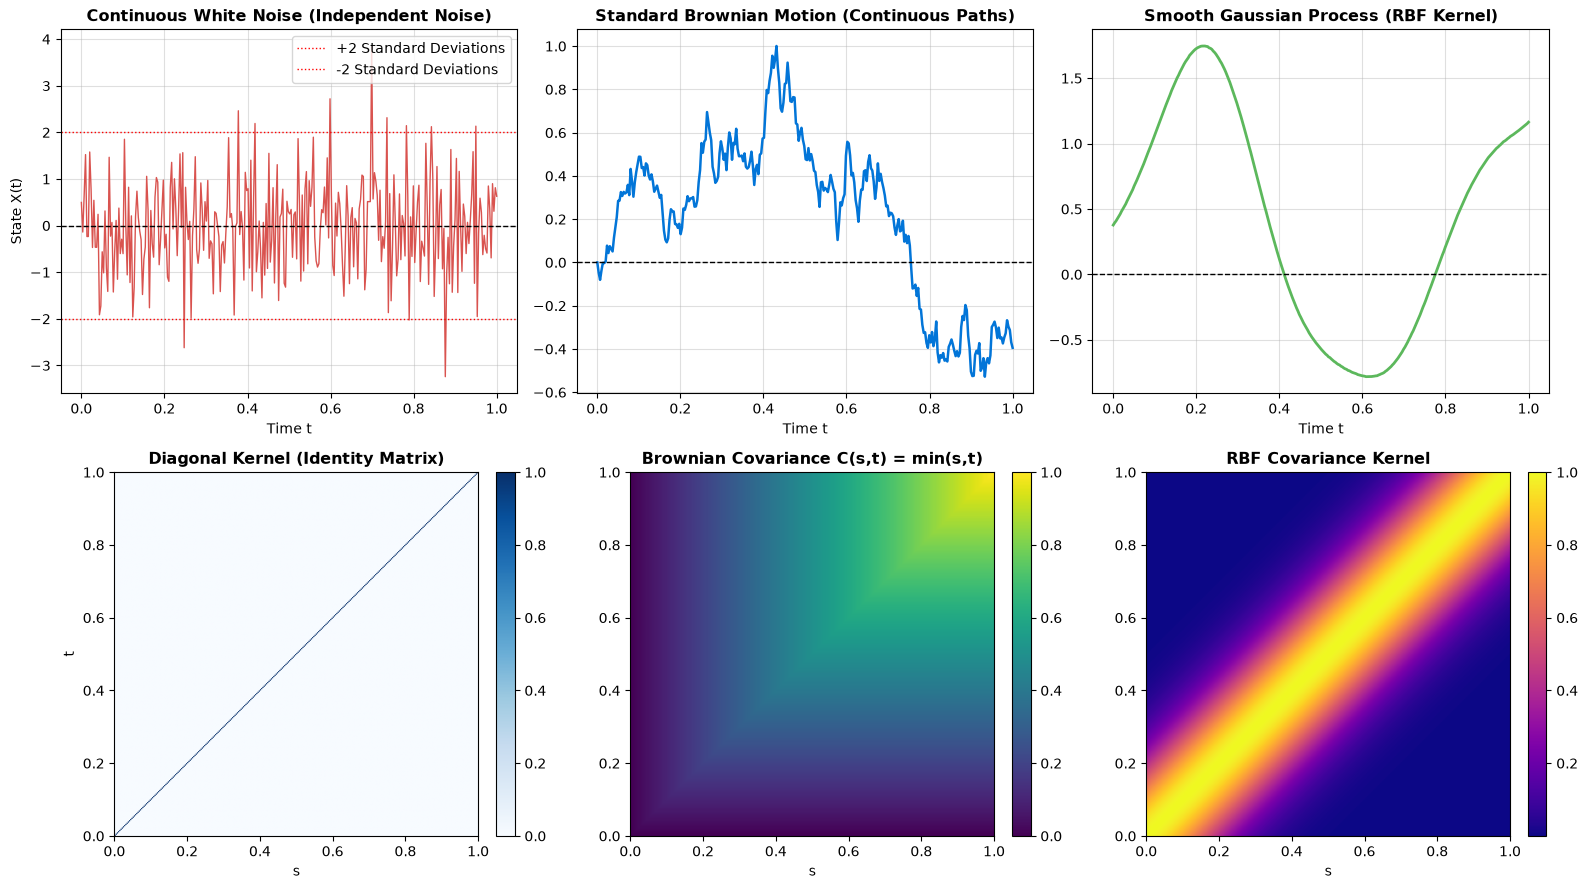

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Time Grid
N = 300
t_grid = np.linspace(0.0, 1.0, N)
S, T = np.meshgrid(t_grid, t_grid)

# 1. Continuous White Noise (Approximated on grid)
white_noise_path = np.random.normal(0, 1, N)

# 2. Standard Brownian Motion Kernel: C(s, t) = min(s, t)
K_bm = np.minimum(S, T)
dt = 1.0 / (N - 1)
bm_path = np.zeros(N)
bm_path[1:] = np.cumsum(np.random.normal(0, np.sqrt(dt), N - 1))

# 3. Squared Exponential (RBF) Kernel: C(s, t) = exp(-0.5 * (s-t)^2 / l^2)
length_scale = 0.15
K_rbf = np.exp(-0.5 * ((S - T) ** 2) / (length_scale ** 2)) + 1e-6 * np.eye(N)
L_rbf = np.linalg.cholesky(K_rbf)
rbf_path = L_rbf @ np.random.normal(0, 1, N)

# Plotting Sample Paths and Covariance Heatmaps
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Row 1: Trajectories
axes[0, 0].plot(t_grid, white_noise_path, color='#d9534f', lw=1.0)
axes[0, 0].axhline(0, color='black', lw=1, linestyle='--')
axes[0, 0].axhline(2, color='red', lw=1, linestyle=':', label='+2 Standard Deviations')
axes[0, 0].axhline(-2, color='red', lw=1, linestyle=':', label='-2 Standard Deviations')
axes[0, 0].set_title('Continuous White Noise (Independent Noise)', fontsize=11.5, fontweight='bold')
axes[0, 0].set_xlabel('Time t', fontsize=10)
axes[0, 0].set_ylabel('State X(t)', fontsize=10)
axes[0, 0].grid(True, alpha=0.4)
axes[0, 0].legend(loc='upper right')

axes[0, 1].plot(t_grid, bm_path, color='#0275d8', lw=1.8)
axes[0, 1].axhline(0, color='black', lw=1, linestyle='--')
axes[0, 1].set_title('Standard Brownian Motion (Continuous Paths)', fontsize=11.5, fontweight='bold')
axes[0, 1].set_xlabel('Time t', fontsize=10)
axes[0, 1].grid(True, alpha=0.4)

axes[0, 2].plot(t_grid, rbf_path, color='#5cb85c', lw=2.0)
axes[0, 2].axhline(0, color='black', lw=1, linestyle='--')
axes[0, 2].set_title('Smooth Gaussian Process (RBF Kernel)', fontsize=11.5, fontweight='bold')
axes[0, 2].set_xlabel('Time t', fontsize=10)
axes[0, 2].grid(True, alpha=0.4)

# Row 2: Covariance Kernels Heatmaps
im0 = axes[1, 0].imshow(np.eye(N), extent=[0, 1, 0, 1], origin='lower', cmap='Blues')
axes[1, 0].set_title('Diagonal Kernel (Identity Matrix)', fontsize=11.5, fontweight='bold')
axes[1, 0].set_xlabel('s', fontsize=10)
axes[1, 0].set_ylabel('t', fontsize=10)
fig.colorbar(im0, ax=axes[1, 0], fraction=0.046, pad=0.04)

im1 = axes[1, 1].imshow(K_bm, extent=[0, 1, 0, 1], origin='lower', cmap='viridis')
axes[1, 1].set_title('Brownian Covariance C(s,t) = min(s,t)', fontsize=11.5, fontweight='bold')
axes[1, 1].set_xlabel('s', fontsize=10)
fig.colorbar(im1, ax=axes[1, 1], fraction=0.046, pad=0.04)

im2 = axes[1, 2].imshow(K_rbf, extent=[0, 1, 0, 1], origin='lower', cmap='plasma')
axes[1, 2].set_title('RBF Covariance Kernel', fontsize=11.5, fontweight='bold')
axes[1, 2].set_xlabel('s', fontsize=10)
fig.colorbar(im2, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()